# Goal of this notebook is to analyze pert theory's dependence on v

Basically, we think that we can expand the pertubation theory in orders of $v$, the quench speed. WE can look at the results of $\delta O $ to see exactly what it should scale like with $v= \dot{\lambda}=\frac{1}{\tau}$

In [1]:
import sys 
sys.path.append("../../src")
import equilibrium_critical_correlations as eq
import kibble_zurek as kz
import kblock_ising_model as kb
from common_imports import *



In [63]:
L = 500
taus = np.logspace(-1, 3, 100)
states = [kz.state(L,tau,0) for tau in tqdm(taus)]

100%|██████████| 100/100 [02:00<00:00,  1.21s/it]


In [67]:
ns = [2,6,12]

# equilibrium values
xx_eq = {n: eq.P_n(n) for n in ns}

# KZ values for each state, for each n
xx_kz = {n: np.array([kz.P_n(n, s) for s in tqdm(states)]) for n in ns}

# differences
xx_diff = {n: xx_kz[n] - xx_eq[n] for n in ns}

100%|██████████| 100/100 [01:01<00:00,  1.64it/s]


[]

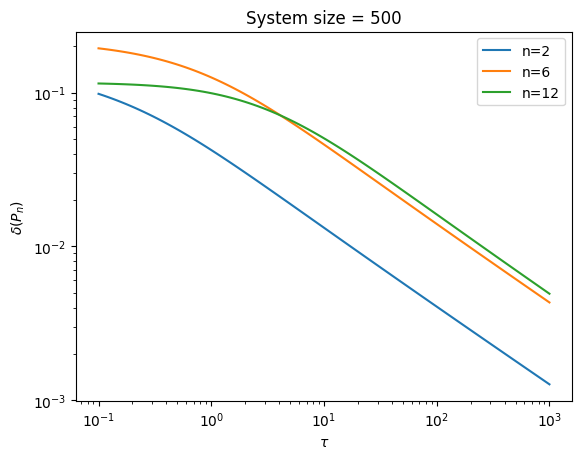

In [68]:
for n in ns:
    plot(taus, abs(xx_diff[n]), label=f"n={n}")
xlabel(r"$\tau$")
ylabel(r"$\delta (P_n)$")
title(f"System size = {L}")
legend()
loglog()